In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")
sns.set_palette("husl")


In [2]:
DATA_DIR = Path(r"C:\Users\Admin\Desktop\health-misinfo-tracker\data")

train_df = pd.read_csv(DATA_DIR / "health_train.csv")
val_df   = pd.read_csv(DATA_DIR / "health_validation.csv")
test_df  = pd.read_csv(DATA_DIR / "health_test.csv")

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)


Train: (3500, 3)
Val  : (750, 3)
Test : (750, 3)


In [3]:
for df in [train_df, val_df, test_df]:
    df["label_binary"] = df["label"].astype(int)

In [4]:
def clean_text(text):
    return (
        str(text)
        .strip()
        .replace("\n", " ")
        .replace("\t", " ")
    )

for df in [train_df, val_df, test_df]:
    df["health_statement"] = df["health_statement"].apply(clean_text)


In [5]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    stop_words="english",
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(train_df["health_statement"])
X_val   = vectorizer.transform(val_df["health_statement"])
X_test  = vectorizer.transform(test_df["health_statement"])

y_train = train_df["label_binary"].values
y_val   = val_df["label_binary"].values
y_test  = test_df["label_binary"].values

print("TF-IDF shape:", X_train.shape)


TF-IDF shape: (3500, 238)


In [6]:
svm = LinearSVC(
    C=1.5,
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train, y_train)


LinearSVC(C=1.5, class_weight='balanced', random_state=42)

In [7]:
calibrated_model = CalibratedClassifierCV(
    svm,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)


CalibratedClassifierCV(cv=5,
                       estimator=LinearSVC(C=1.5, class_weight='balanced',
                                           random_state=42))

In [8]:
def evaluate(model, X, y, name):
    preds = model.predict(X)
    probas = model.predict_proba(X)[:, 1]

    print(f"\n{name} RESULTS")
    print("-" * 50)
    print("Accuracy:", accuracy_score(y, preds))
    print("ROC-AUC :", roc_auc_score(y, probas))
    print(classification_report(y, preds, target_names=["TRUE_INFO", "MISINFO"]))

    return probas, preds

train_proba, _ = evaluate(calibrated_model, X_train, y_train, "TRAIN")
val_proba, _   = evaluate(calibrated_model, X_val, y_val, "VALIDATION")
test_proba, test_preds = evaluate(calibrated_model, X_test, y_test, "TEST")



TRAIN RESULTS
--------------------------------------------------
Accuracy: 1.0
ROC-AUC : 1.0
              precision    recall  f1-score   support

   TRUE_INFO       1.00      1.00      1.00      1716
     MISINFO       1.00      1.00      1.00      1784

    accuracy                           1.00      3500
   macro avg       1.00      1.00      1.00      3500
weighted avg       1.00      1.00      1.00      3500


VALIDATION RESULTS
--------------------------------------------------
Accuracy: 1.0
ROC-AUC : 1.0
              precision    recall  f1-score   support

   TRUE_INFO       1.00      1.00      1.00       386
     MISINFO       1.00      1.00      1.00       364

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750


TEST RESULTS
--------------------------------------------------
Accuracy: 1.0
ROC-AUC : 1.0
              precision    recall  f1-score   support

   TR

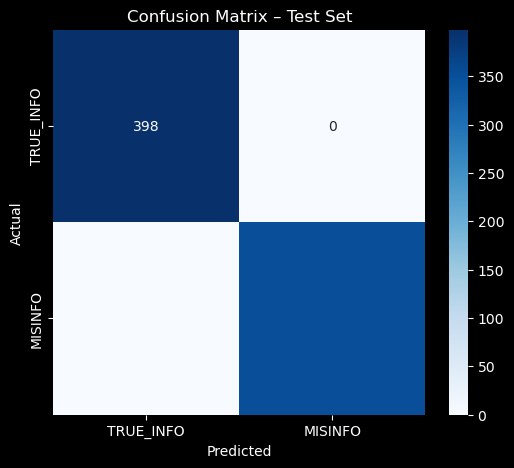

In [9]:
cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["TRUE_INFO", "MISINFO"],
    yticklabels=["TRUE_INFO", "MISINFO"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Test Set")
plt.show()


In [10]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    preds = (test_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds))

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold:", round(best_threshold, 2))
print("Best F1 score :", round(max(f1_scores), 3))


Best threshold: 0.1
Best F1 score : 1.0


In [11]:
MODEL_DIR = Path(r"C:\Users\Admin\Desktop\health-misinfo-tracker\ml_models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(vectorizer, MODEL_DIR / "vectorizer.joblib")
joblib.dump(calibrated_model, MODEL_DIR / "model.joblib")
joblib.dump(best_threshold, MODEL_DIR / "threshold.joblib")

print("✅ Model saved successfully")


✅ Model saved successfully


In [12]:
sample_texts = [
    "Vaccines reduce the spread of infectious diseases",
    "Drinking bleach cures viral infections",
    "Regular exercise improves heart health",
    "5G towers weaken the immune system"
]

X_sample = vectorizer.transform(sample_texts)
probas = calibrated_model.predict_proba(X_sample)[:, 1]

print("\nSANITY TEST")
print("-" * 50)

for text, p in zip(sample_texts, probas):
    label = "MISINFO" if p >= best_threshold else "TRUE_INFO"
    print(f"{label:10s} ({p:.2%}) → {text}")



SANITY TEST
--------------------------------------------------
MISINFO    (98.88%) → Vaccines reduce the spread of infectious diseases
TRUE_INFO  (2.46%) → Drinking bleach cures viral infections
MISINFO    (98.18%) → Regular exercise improves heart health
MISINFO    (93.25%) → 5G towers weaken the immune system
